# Determining Drag Area Coefficient from Cruising Tests

**Author:** Ryan Huang

**Date:** 2026-05-16

**Relevant Links:**
- [Monday Item](https://ubcsolar26.monday.com/boards/9565353662/views/211183038/pulses/11675714971)
- This analysis reuses some code from the [2025 Brightside Cruise Test](https://github.com/UBC-Solar/data_analysis/blob/main/v3/motor_analysis/motor_testing_april_6.ipynb)

The goal of this analysis is to produce a reasonable CdA (drag coefficient * area) value. This is done through analyzing cruising tests that were performed on Apr 2, 2026, at the McArthur Glen Designer Outlet parking lot. 

6 cruising tests were performed, but this analysis will only use the first 4 as regenerative braking was likely active for the last 2 (during the tests, Pack Current had negative values on InfluxDB, although RegenEnabled read 0)

## Imports

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from data_tools.collections import TimeSeries
from data_tools.query import DBClient
from datetime import datetime
from scipy import stats
from scipy.signal import savgol_filter

## Data Acquisition

First, we extract the four cruise tests done without regenerative braking. The data must be fetched from InfluxDB every time because self.ureg inside TimeSeries cannot be serialized.

I first manually identified each cruise test. Each START_TIME and its corresponding STOP_TIME spans the acceleration time, cruising time, and braking time. 

In [5]:
START_TIMES = [datetime.fromisoformat("2026-04-02T20:02:25Z"),
                datetime.fromisoformat("2026-04-02T20:07:05Z"),
                datetime.fromisoformat("2026-04-02T20:25:57Z"),
                datetime.fromisoformat("2026-04-02T20:35:34Z"),]
    
STOP_TIMES = [datetime.fromisoformat("2026-04-02T20:03:02Z"),
                datetime.fromisoformat("2026-04-02T20:07:31Z"),
                datetime.fromisoformat("2026-04-02T20:26:38Z"),
                datetime.fromisoformat("2026-04-02T20:36:12Z"),]


Next, I queried MotorRotatingSpeed, PackCurrent, BrakePressed, and Acceleration_Z from Influx. PackCurrent is used to identify the start of the cruising period, BrakePressed identifies the end, and Acceleration_Z is IMU acceleration, which I"ll try using in addition to deriving the speed.

In [6]:
client = DBClient()
PACK_CURRENT_THRESHOLD = 0.10682  # pack current never reads 0; its lowest value is this constant (constant is rounded up here)

cruise_speeds: list[TimeSeries] = []
cruise_pack_currents: list[TimeSeries] = []    
cruise_brake_presseds: list[TimeSeries] = []     
cruise_imu_zs: list[TimeSeries] = []

for start, stop in zip(START_TIMES, STOP_TIMES):
    motor_rotating_speed: TimeSeries = client.query_time_series(start=start, stop=stop, field="MotorRotatingSpeed", units="km/h")
    pack_current: TimeSeries = client.query_time_series(start=start, stop=stop, field="PackCurrent", units="A")
    brake_pressed: TimeSeries = client.query_time_series(start=start, stop=stop, field="BrakePressed")
    imu_z: TimeSeries = client.query_time_series(start=start, stop=stop, field="Acceleration_Z")

    motor_rotating_speed, pack_current, brake_pressed, imu_z = TimeSeries.align( # different sampling rates for each data, so we align early to save headaches later
        motor_rotating_speed, pack_current, brake_pressed, imu_z
    ) 

    cruise_speeds.append(motor_rotating_speed)
    cruise_pack_currents.append(pack_current)
    cruise_brake_presseds.append(brake_pressed)
    cruise_imu_zs.append(imu_z)

## Analysis

### Plots of the entire cruise, from start to stop

First, let's visualize each run in this notebook with speed vs time and acceleration vs time graphs for the entire run (from when the car speeds up from rest to when the car reaches 0 km/h again)

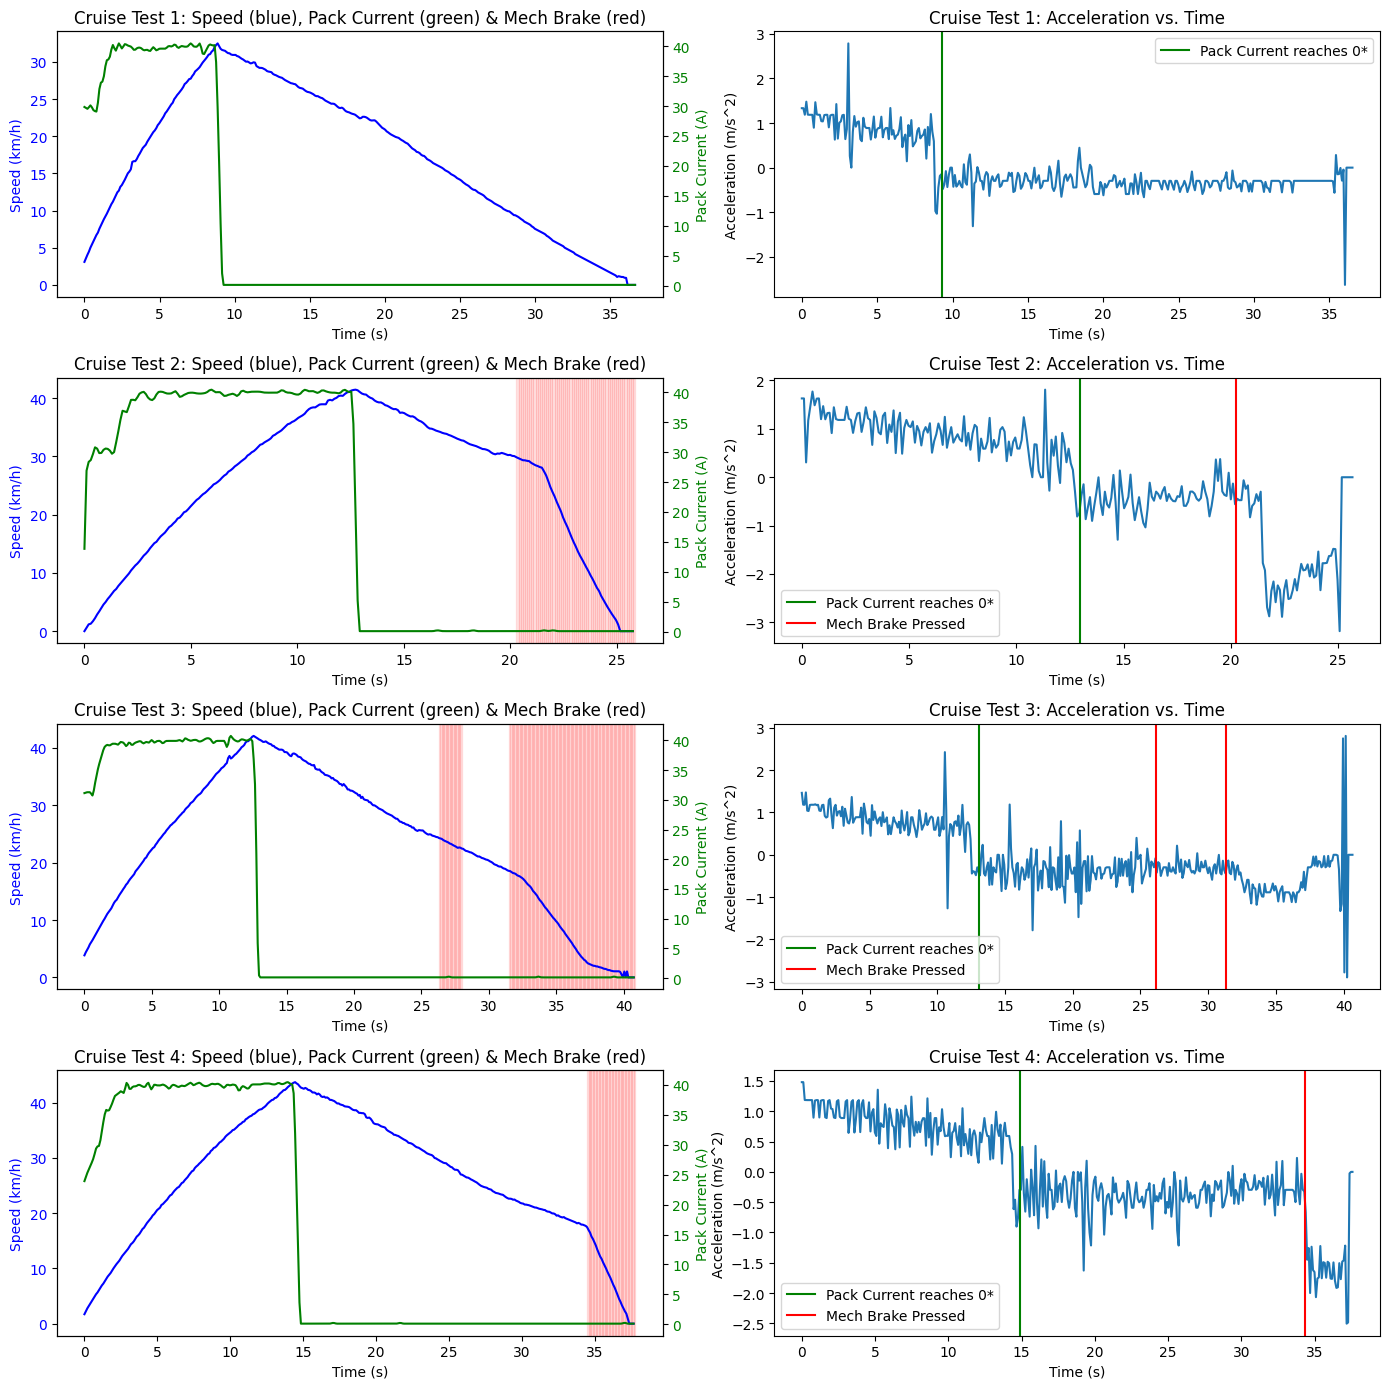

In [7]:
KMH_PER_MPS = 3.6
fig, axes = plt.subplots(4, 2, figsize=(14, 14))

for i, (speed, current, brake) in enumerate(zip(cruise_speeds, cruise_pack_currents, cruise_brake_presseds)):
    t_axis = speed.x_axis
    period = speed.period
    acceleration = (np.diff(np.asarray(speed)) / period) / KMH_PER_MPS  # np.asarray(speed) turns TimeSeries into a basic np.ndarray, guaranteeing these operations work

    # Left plot: speed and pack current
    ax1 = axes[i, 0]
    ax1.plot(t_axis, speed, color="blue")
    ax1.set_xlabel("Time (s)")
    ax1.set_ylabel("Speed (km/h)", color="blue")
    ax1.tick_params(axis="y", labelcolor="blue")
    ax1.set_title(f"Cruise Test {i+1}: Speed (blue), Pack Current (green) & Mech Brake (red)")

    ax2 = ax1.twinx()
    ax2.plot(t_axis, current, color="green")
    ax2.set_ylabel("Pack Current (A)", color="green")
    ax2.tick_params(axis="y", labelcolor="green")

    for j, value in enumerate(brake):
        if value == 1:
            ax1.axvspan(t_axis[j], t_axis[j]+period, color="red", alpha=0.1)  # Highlight background when brake is pressed
    
    # Right plot: acceleration
    ax3 = axes[i, 1]
    ax3.plot(t_axis[:-1], acceleration)  # np.diff results in a 1 item shorter array

    cruise_start_time = np.where(current <= PACK_CURRENT_THRESHOLD)[0][0] * period
    ax3.axvline(cruise_start_time, c="green", label = "Pack Current reaches 0*") # star because current technically reaches PACK_CURRENT_THRESHOLD. I am assuming it is a sensor issue?

    brake_indices = np.where(brake > 0)[0]
    if brake_indices.size > 0:
        # in this if statement, I"m identifying brake "groups" (i.e. each time the brake was pressed down) and plottng each group as a separate line. 
        gap_indices = np.where(np.diff(brake_indices) > 1)[0]
        brake_start_indices = np.concatenate([[brake_indices[0]], brake_indices[gap_indices + 1]])
        for j, brake_start_index in enumerate(brake_start_indices):
            brake_time = brake_start_index * period
            label = "Mech Brake Pressed" if j == 0 else "_nolegend_"
            ax3.axvline(brake_time, c="red", label = label)

    ax3.set_xlabel("Time (s)")
    ax3.set_ylabel("Acceleration (m/s^2)")
    ax3.legend()
    ax3.set_title(f"Cruise Test {i+1}: Acceleration vs. Time")

plt.tight_layout()
plt.show()


### Extracting the cruise test windows

The cruise test is the section of the run where the only forces acting on the car are rolling resistance and drag. This is the section where pack current drops to 0 and the mech brake as not been pressed yet. For each test, we"ll extract the speed as a TimeSeries during this window.

In [8]:
cruise_window_speeds: list[TimeSeries] = []          
cruise_windows: list[tuple[datetime, datetime]] = [] # to extract IMU acceleration cruise window later on

for speed, current, brake in zip(cruise_speeds, cruise_pack_currents, cruise_brake_presseds):
    cruise_start_index = np.where(current <= PACK_CURRENT_THRESHOLD)[0][0]

    brake_indices = np.where(brake > 0)[0]
    if brake_indices.size == 0:
        # for runs where brake wasn't pressed, end the cruise when speed == 0
        zero_speed_indices = np.where(speed == 0)[0]
        cruise_end_index = zero_speed_indices[0]        
    else:    
        cruise_end_index = brake_indices[0]

    cruise_start_time = current.datetime_x_axis[cruise_start_index]
    cruise_end_time = brake.datetime_x_axis [cruise_end_index]
    cruise_windows.append((cruise_start_time, cruise_end_time))

    cruise_window_speed = speed.slice(cruise_start_time, cruise_end_time)

    cruise_window_speeds.append(cruise_window_speed)

Now, we can plot acceleration vs speed and decelerating force vs speed during the cruising window.

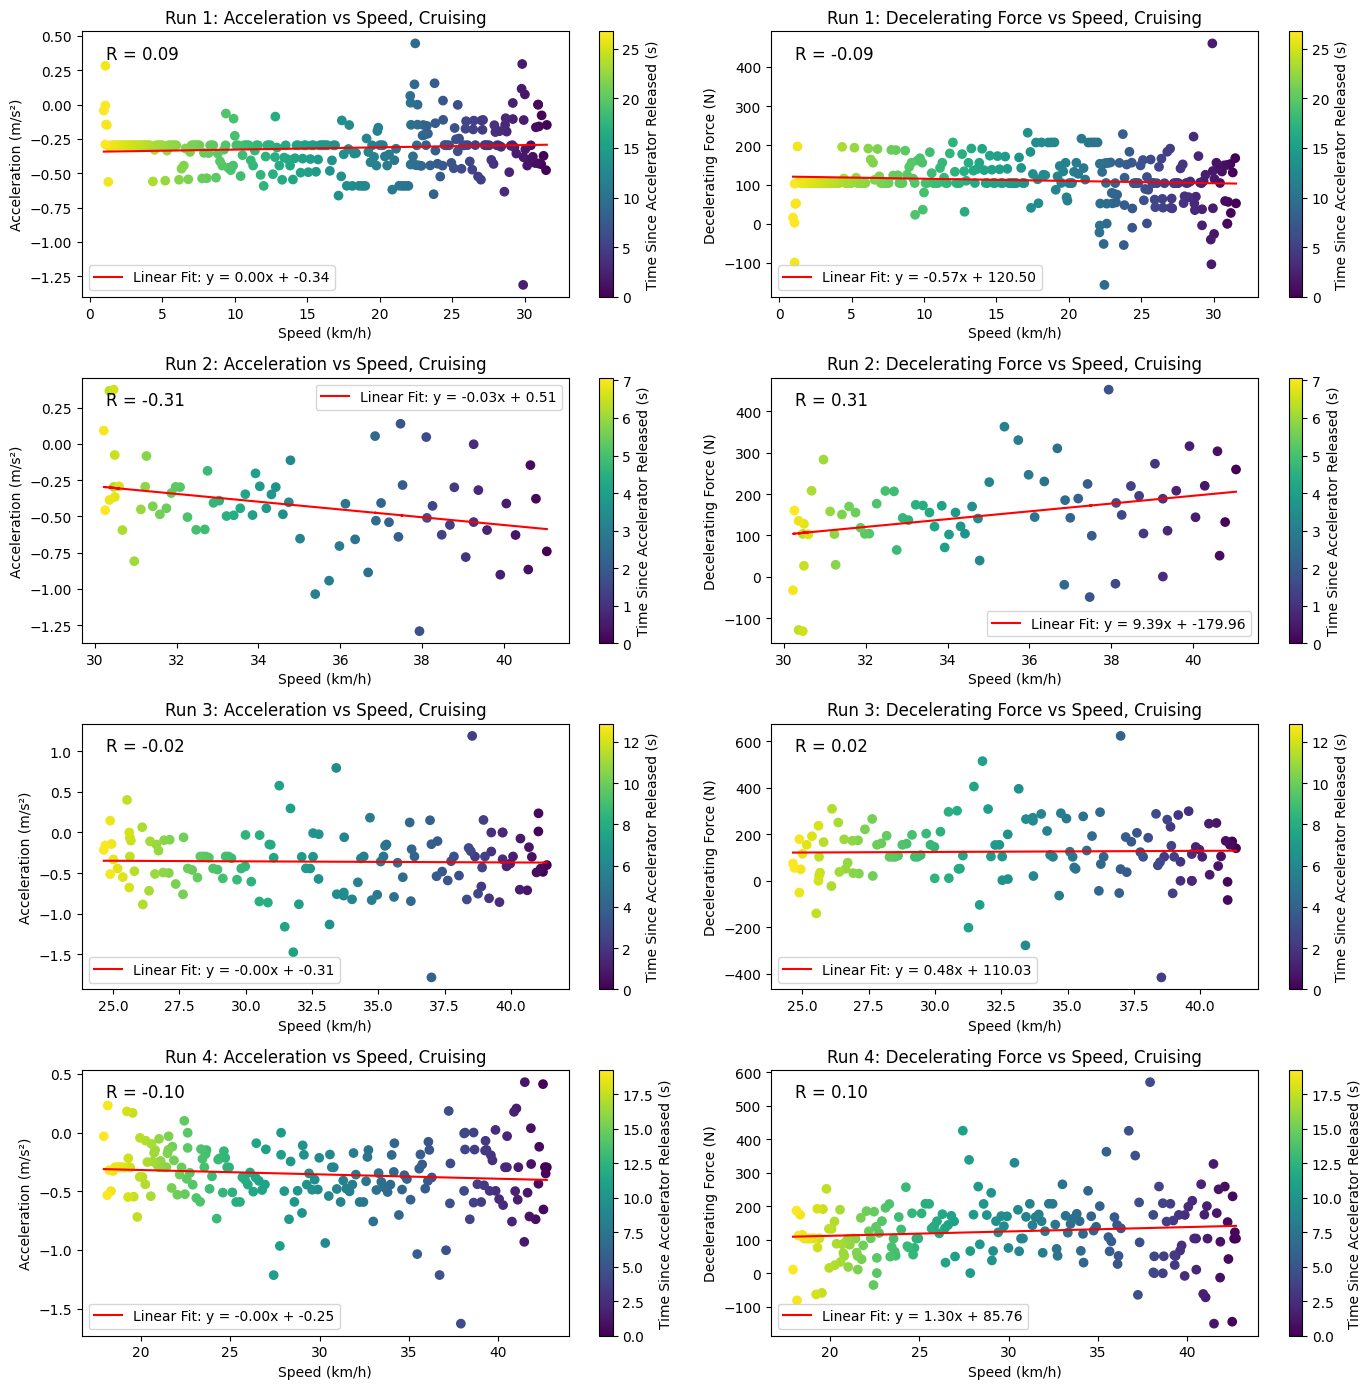

In [9]:
BRIGHTSIDE_MASS_KG = 350 # value taken from the 2025 analysis
fig, axes = plt.subplots(4, 2, figsize=(14, 14))

for i, speed in enumerate(cruise_window_speeds):
    t_axis = speed.x_axis
    period = speed.period

    acceleration = (np.diff(np.asarray(speed)) / period) / KMH_PER_MPS
    force = BRIGHTSIDE_MASS_KG * acceleration * -1 # F = ma, and flip sign to get slowing force
    speed_without_last = speed[:-1]
    time_since_cruising = t_axis[:-1] - t_axis[0]

    ax1 = axes[i, 0]
    ax2 = axes[i, 1]

    for ax, y_data, y_label, title in [
        (ax1, acceleration, "Acceleration (m/s²)", f"Run {i+1}: Acceleration vs Speed, Cruising"),
        (ax2, force, "Decelerating Force (N)", f"Run {i+1}: Decelerating Force vs Speed, Cruising"),
    ]:  
    
        slope, intercept, r_value, _, _ = stats.linregress(speed_without_last, y_data)
        fit_line = slope * np.asarray(speed_without_last) + intercept

        
        scatter = ax.scatter(speed_without_last, y_data, c=time_since_cruising)
        ax.set_title(title)
        ax.set_xlabel("Speed (km/h)")
        ax.set_ylabel(y_label)
        fig.colorbar(scatter, label="Time Since Accelerator Released (s)", ax=ax)

        ax.text(0.05, 0.95, f"R = {r_value:.2f}", transform=ax.transAxes, fontsize=12, verticalalignment="top")

        ax.plot(speed_without_last, fit_line, color="red", label=f"Linear Fit: y = {slope:.2f}x + {intercept:.2f}")
        ax.legend()
    

plt.tight_layout()
plt.show()


Colors I'll reuse for plotting

In [10]:
COLORS = ["red", "orange", "green", "blue"]

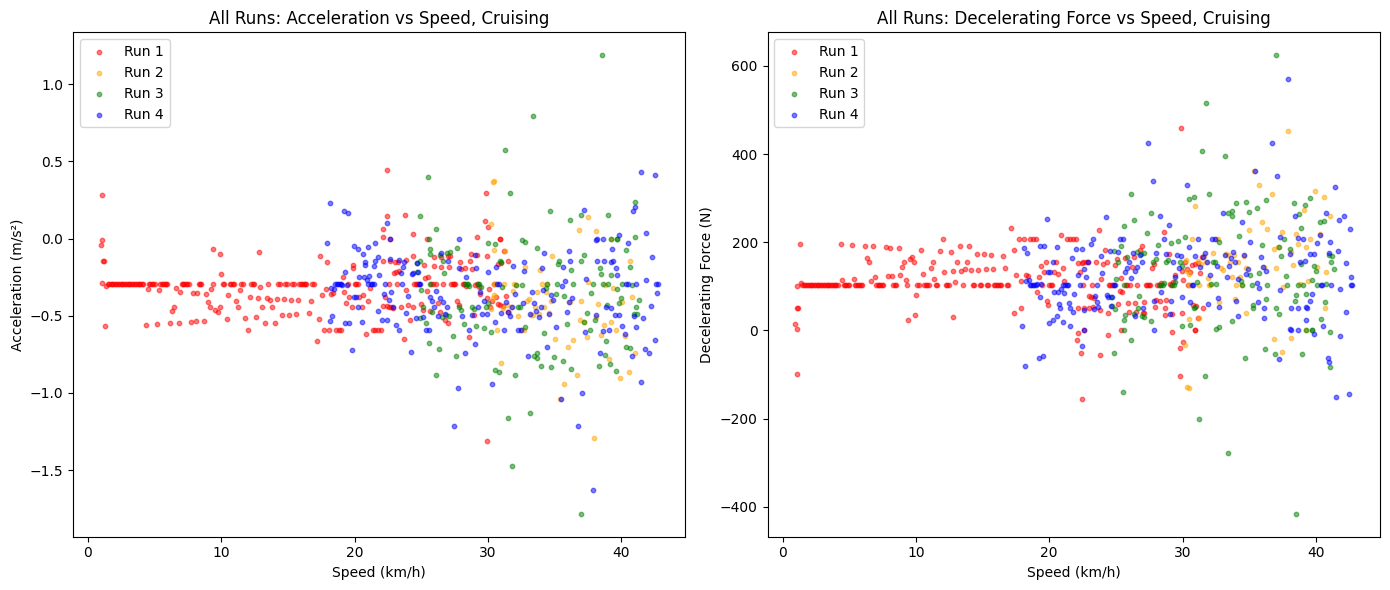

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax_accel, ax_force = axes

for i, speed in enumerate(cruise_window_speeds):
    t_axis = speed.x_axis
    period = speed.period

    speed_array = np.asarray(speed)
    acceleration: np.ndarray = (np.diff(speed_array) / period) / KMH_PER_MPS
    force = BRIGHTSIDE_MASS_KG * acceleration * -1
    speed_without_last = speed_array[:-1]

    color = COLORS[i]

    for ax, y_data, y_label, title in [
        (ax_accel, acceleration, "Acceleration (m/s²)", "All Runs: Acceleration vs Speed, Cruising"),
        (ax_force, force, "Decelerating Force (N)", "All Runs: Decelerating Force vs Speed, Cruising"),
    ]:
        ax.scatter(speed_without_last, y_data, c=color, alpha=0.5, s=10, label=f"Run {i+1}")

        ax.set_title(title)
        ax.set_xlabel("Speed (km/h)")
        ax.set_ylabel(y_label)
        ax.legend()
        
plt.tight_layout()
plt.show()

### Experimenting with filtering

Let's try using the Savitsky-Golay filter to try and filter out some noise  
Note: I tested a few common WINDOW and POLY values but didn't do any rigorous tuning because a) All the manually tested results seemed similar and I'm not sure tuning these parameters will make a big difference and b) I'm not too familiar with these filters and would have to learn more about them (for example, if there are metrics to evaluate the "goodness" of a filter), which I feel like wouldn't be a good use of time because of point a.

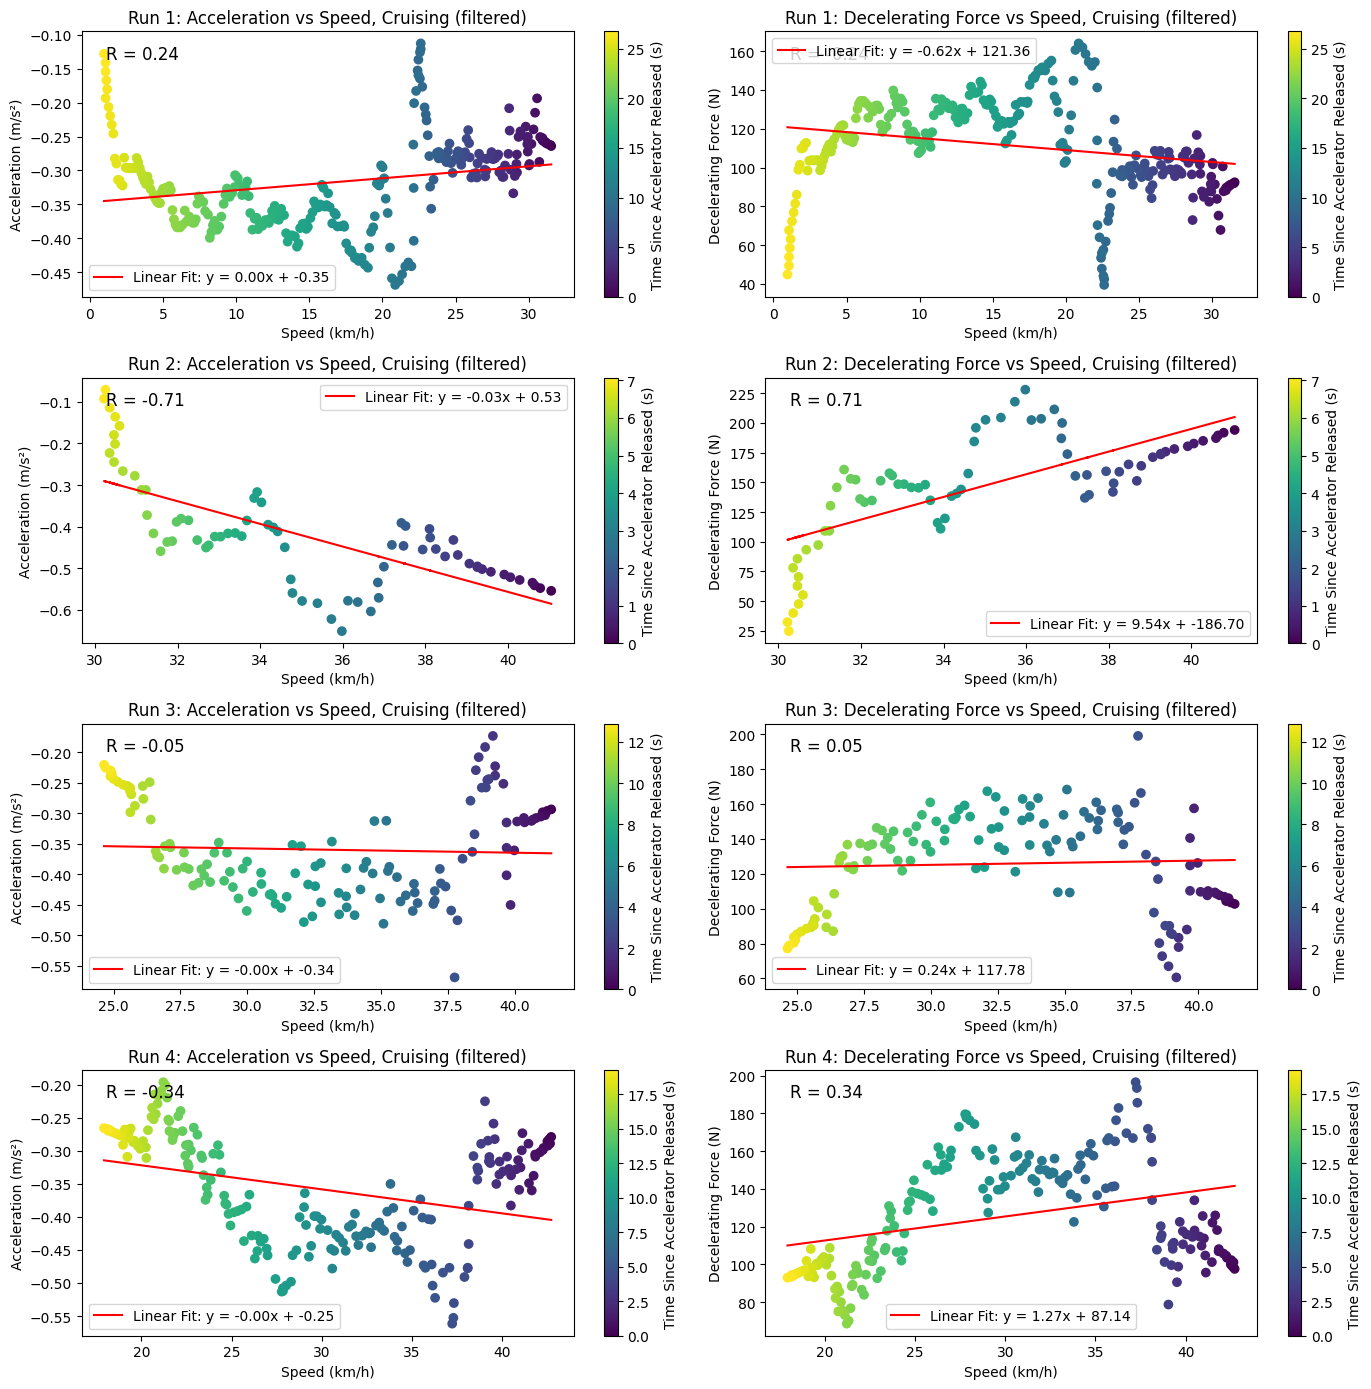

In [12]:
SAVGOL_WINDOW = 21    # number of points in each window, must be odd.
SAVGOL_POLY = 2       # polynomial order.

fig, axes = plt.subplots(4, 2, figsize=(14, 14))

for i, speed in enumerate(cruise_window_speeds):
    t_axis = speed.x_axis
    period = speed.period

    speed_array = np.asarray(speed)
    speed_smoothed = savgol_filter(speed_array, SAVGOL_WINDOW, SAVGOL_POLY)

    acceleration: np.ndarray = (np.diff(speed_smoothed) / period) / KMH_PER_MPS
    force = BRIGHTSIDE_MASS_KG * acceleration * -1
    speed_without_last = speed_array[:-1]          
    time_since_cruising = t_axis[:-1] - t_axis[0]

    ax1 = axes[i, 0]
    ax2 = axes[i, 1]

    for ax, y_data, y_label, title in [
        (ax1, acceleration, "Acceleration (m/s²)", f"Run {i+1}: Acceleration vs Speed, Cruising (filtered)"),
        (ax2, force, "Decelerating Force (N)", f"Run {i+1}: Decelerating Force vs Speed, Cruising (filtered)"),
    ]:
        slope, intercept, r_value, _, _ = stats.linregress(speed_without_last, y_data)
        fit_line = slope * speed_without_last + intercept

        scatter = ax.scatter(speed_without_last, y_data, c=time_since_cruising)
        ax.set_title(title)
        ax.set_xlabel("Speed (km/h)")
        ax.set_ylabel(y_label)
        fig.colorbar(scatter, label="Time Since Accelerator Released (s)", ax=ax)
        ax.text(0.05, 0.95, f"R = {r_value:.2f}", transform=ax.transAxes, fontsize=12, verticalalignment="top")
        ax.plot(speed_without_last, fit_line, color="red", label=f"Linear Fit: y = {slope:.2f}x + {intercept:.2f}")
        ax.legend()
        

plt.tight_layout()
plt.show()

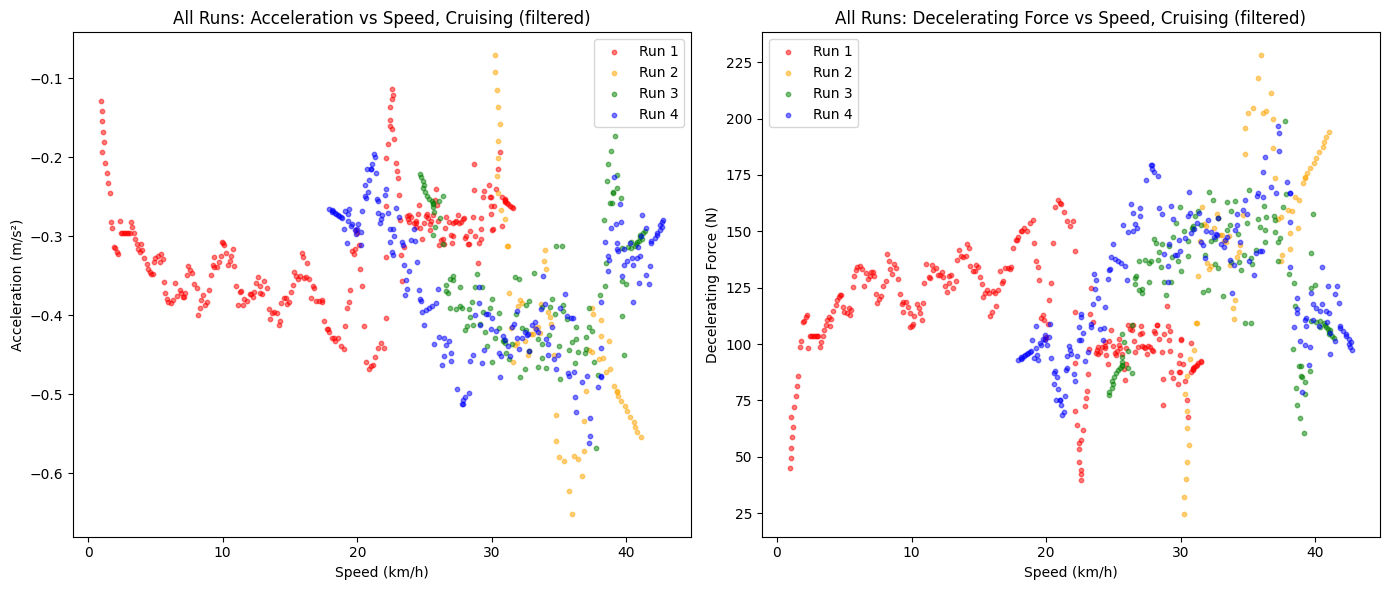

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax_accel, ax_force = axes

for i, speed in enumerate(cruise_window_speeds):
    t_axis = speed.x_axis
    period = speed.period

    speed_array = np.asarray(speed)
    speed_smoothed: np.ndarray = savgol_filter(speed_array, SAVGOL_WINDOW, SAVGOL_POLY)

    acceleration: np.ndarray = (np.diff(speed_smoothed) / period) / KMH_PER_MPS
    force = BRIGHTSIDE_MASS_KG * acceleration * -1
    speed_without_last = speed_array[:-1]

    color = COLORS[i]

    for ax, y_data, y_label, title in [
        (ax_accel, acceleration, "Acceleration (m/s²)", "All Runs: Acceleration vs Speed, Cruising (filtered)"),
        (ax_force, force, "Decelerating Force (N)", "All Runs: Decelerating Force vs Speed, Cruising (filtered)"),
    ]:
        ax.scatter(speed_without_last, y_data, c=color, alpha=0.5, s=10, label=f"Run {i+1}")

        ax.set_title(title)
        ax.set_xlabel("Speed (km/h)")
        ax.set_ylabel(y_label)
        ax.legend()
        
plt.tight_layout()
plt.show()

### experimenting with IMU acceleration

In [14]:
# period of time where car is not moving
STATIC_START_TIME = datetime.fromisoformat("2026-04-02T20:04:00Z")
STATIC_STOP_TIME = datetime.fromisoformat("2026-04-02T20:07:00Z")
imu_z_static: TimeSeries = client.query_time_series(start=STATIC_START_TIME, stop=STATIC_STOP_TIME, field="Acceleration_Z")
z_static_accel = float(np.mean(imu_z_static)) # want to subtract this as a number below, not as a TimeSeries 

cruise_window_imu_zs: list[TimeSeries] = []
G = 9.81
for i, imu_z in enumerate(cruise_imu_zs):
    zeroed_imu_z = imu_z - z_static_accel
    cruise_window_imu_zs.append(zeroed_imu_z.slice(cruise_windows[i][0], cruise_windows[i][1]) / 1000 * G)

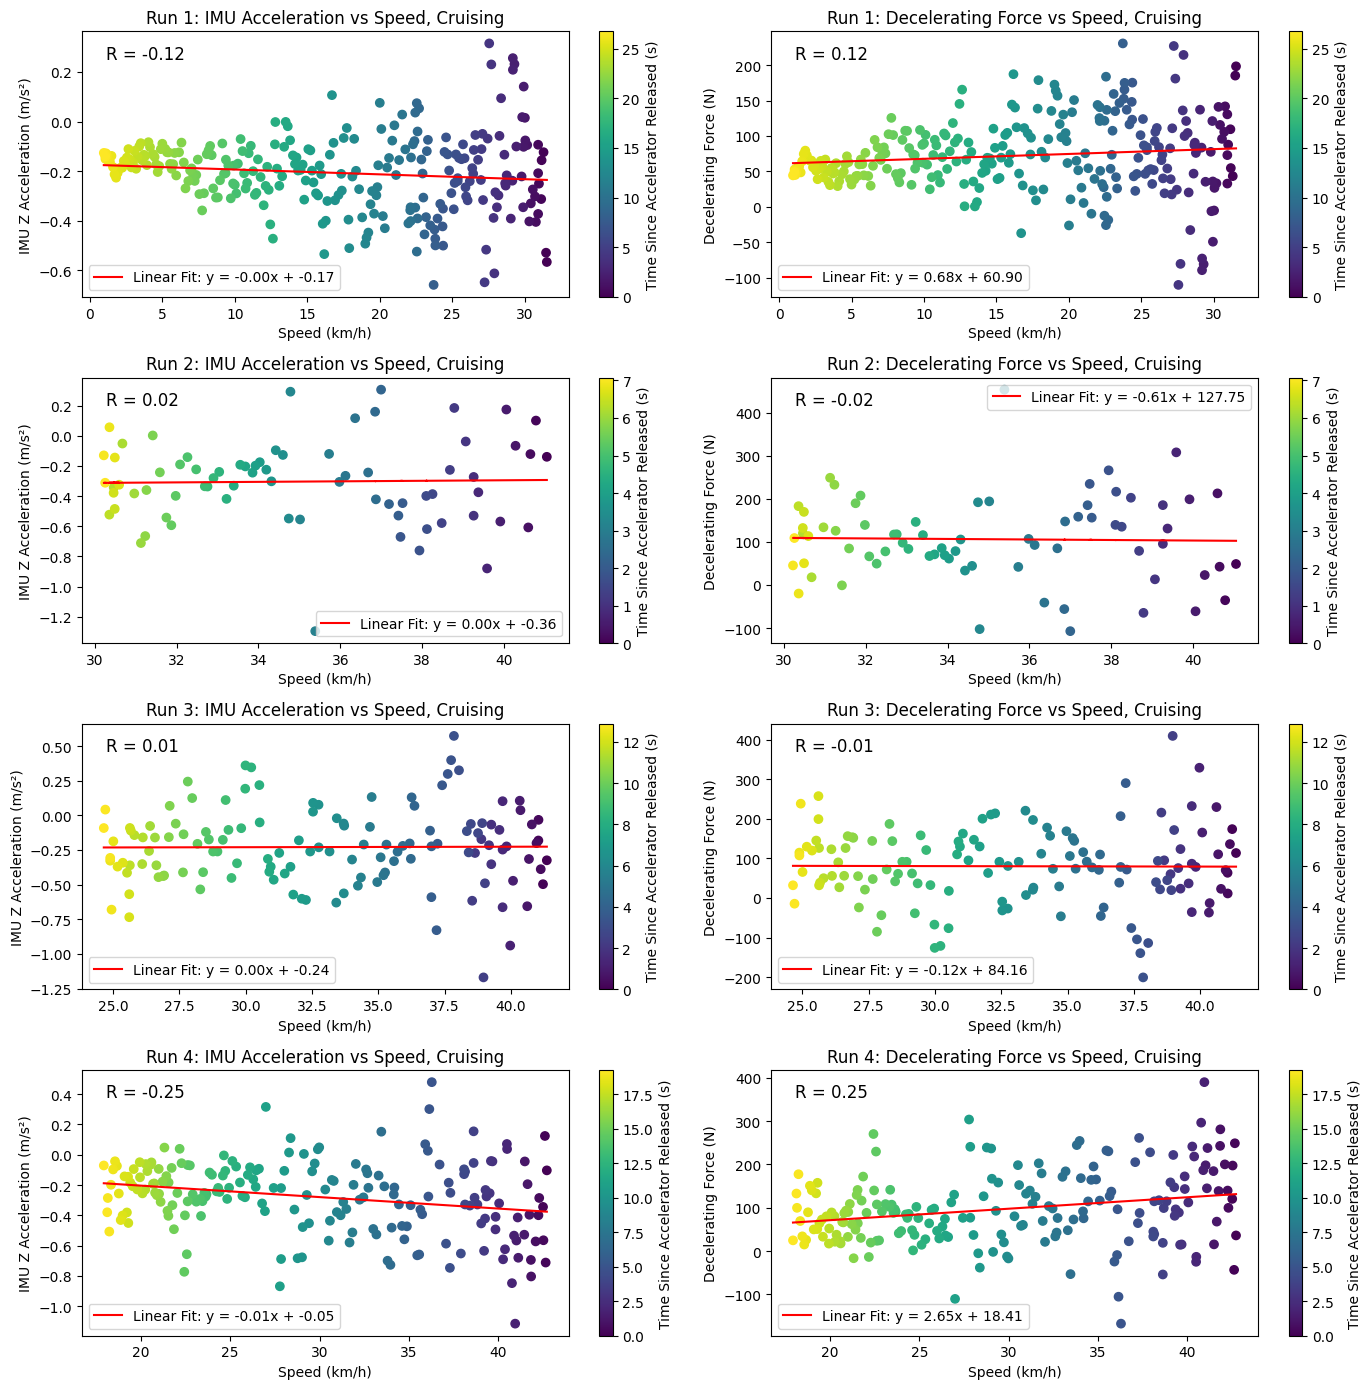

In [15]:
fig, axes = plt.subplots(4, 2, figsize=(14, 14))

for i, (speed, imu_z) in enumerate(zip(cruise_window_speeds, cruise_window_imu_zs)):
    t_axis = speed.x_axis
    period = speed.period

    speed_without_last = np.asarray(speed[:-1])
    imu_z_without_last = np.asarray(imu_z[:-1])
    force = BRIGHTSIDE_MASS_KG * imu_z_without_last * -1
    time_since_cruising = t_axis[:-1] - t_axis[0]

    ax1 = axes[i, 0]
    ax2 = axes[i, 1]

    for ax, y_data, y_label, title in [
        (ax1, imu_z_without_last, "IMU Z Acceleration (m/s²)", f"Run {i+1}: IMU Acceleration vs Speed, Cruising"),
        (ax2, force, "Decelerating Force (N)", f"Run {i+1}: Decelerating Force vs Speed, Cruising"),
    ]:
        slope, intercept, r_value, _, _ = stats.linregress(speed_without_last, y_data)
        fit_line = slope * speed_without_last + intercept

        scatter = ax.scatter(speed_without_last, y_data, c=time_since_cruising)
        ax.plot(speed_without_last, fit_line, color="red", label=f"Linear Fit: y = {slope:.2f}x + {intercept:.2f}")
        ax.text(0.05, 0.95, f"R = {r_value:.2f}", transform=ax.transAxes, fontsize=12, verticalalignment="top")
        fig.colorbar(scatter, label="Time Since Accelerator Released (s)", ax=ax)
        ax.set_title(title)
        ax.set_xlabel("Speed (km/h)")
        ax.set_ylabel(y_label)
        ax.legend()

plt.tight_layout()
plt.show()

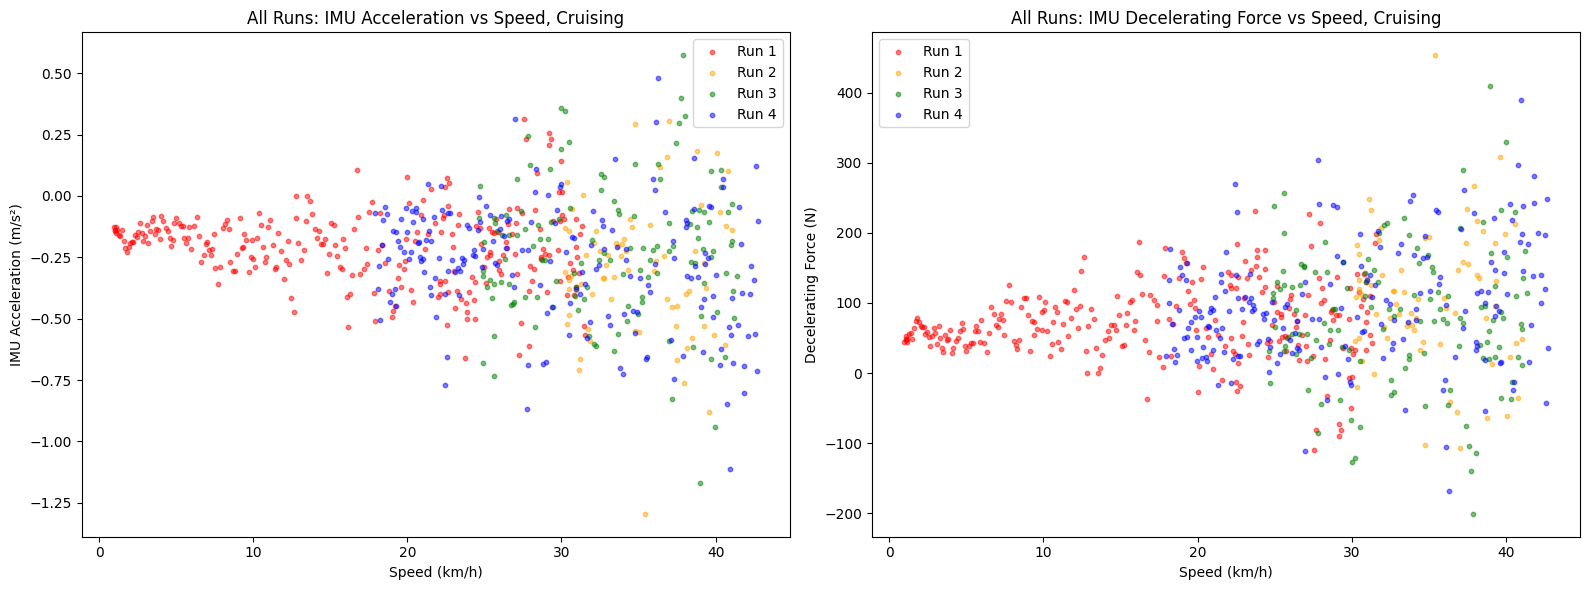

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ax_imu_accel, ax_imu_force = axes
 
for i, (speed, imu_z) in enumerate(zip(cruise_window_speeds, cruise_window_imu_zs)):
    speed_array = np.asarray(speed)
 
    speed_without_last = speed_array[:-1]
    imu_z_without_last = np.asarray(imu_z)[:-1]
    imu_force = BRIGHTSIDE_MASS_KG * imu_z_without_last * -1 
 
    color = COLORS[i]
 
    for ax, y_data, y_label, title in [
        (ax_imu_accel, imu_z_without_last, "IMU Acceleration (m/s²)",   "All Runs: IMU Acceleration vs Speed, Cruising"),
        (ax_imu_force, imu_force,       "Decelerating Force (N)",     "All Runs: IMU Decelerating Force vs Speed, Cruising"),
    ]:
        ax.scatter(speed_without_last, y_data, c=color, alpha=0.5, s=10, label=f"Run {i+1}")

        ax.set_title(title)
        ax.set_xlabel("Speed (km/h)")
        ax.set_ylabel(y_label)
        ax.legend()
 
plt.tight_layout()
plt.show()

In [26]:
cruise_window_speeds[1]

TimeSeries([41.05037668, 40.78456244, 40.64900083, 40.5966773 ,
            40.28578712, 40.06043316, 39.91297607, 39.58932434,
            39.37618649, 39.26197318, 39.26136304, 39.06799284,
            38.7879518 , 38.68072421, 38.48023541, 38.25546611,
            38.10224452, 38.11940476, 37.93643013, 37.47298997,
            37.52314521, 37.42148127, 37.19155957, 36.99774511,
            36.85164689, 36.87125281, 36.68139405, 36.36334624,
            36.12723009, 35.97922894, 35.72655489, 35.38808281,
            35.01633452, 34.78191672, 34.74156158, 34.59724019,
            34.42318918, 34.31648075, 34.19158735, 34.03240181,
            33.92762401, 33.85491895, 33.67889768, 33.55456307,
            33.39539106, 33.21879847, 33.04045332, 32.90014403,
            32.75436767, 32.68791281, 32.47638131, 32.26383668,
            32.082787  , 31.97599049, 31.86971805, 31.74831317,
            31.58917537, 31.41504449, 31.26084497, 31.23110213,
            31.12539477, 30.96351399, 30

### np.polyfit

In [27]:
all_speeds_imu = []
all_accels_imu = []

for speed, imu_z in zip(cruise_window_speeds, cruise_window_imu_zs):
    all_speeds_imu.append(np.asarray(speed)[:-1])
    all_accels_imu.append(np.asarray(imu_z)[:-1])

all_speeds_imu = np.concatenate(all_speeds_imu)
all_accels_imu = np.concatenate(all_accels_imu)

coeffs_accel, cov_accel = np.polyfit(all_speeds_imu, all_accels_imu, deg=2, cov=True)
coeffs_force = coeffs_accel * -BRIGHTSIDE_MASS_KG
cov_force = cov_accel * (BRIGHTSIDE_MASS_KG ** 2)  #??

stdevs_accel = np.sqrt(np.diag(cov_accel))
stdevs_force = np.sqrt(np.diag(cov_force))

v_range = np.linspace(all_speeds_imu.min(), all_speeds_imu.max(), 300)

In [30]:
coeffs_accel

array([-5.79532358e-05, -9.11790670e-04, -1.73891768e-01])

In [29]:
cov_accel

array([[ 4.54547186e-09, -2.06011077e-07,  1.76571906e-06],
       [-2.06011077e-07,  9.96385502e-06, -9.61463415e-05],
       [ 1.76571906e-06, -9.61463415e-05,  1.17294896e-03]])

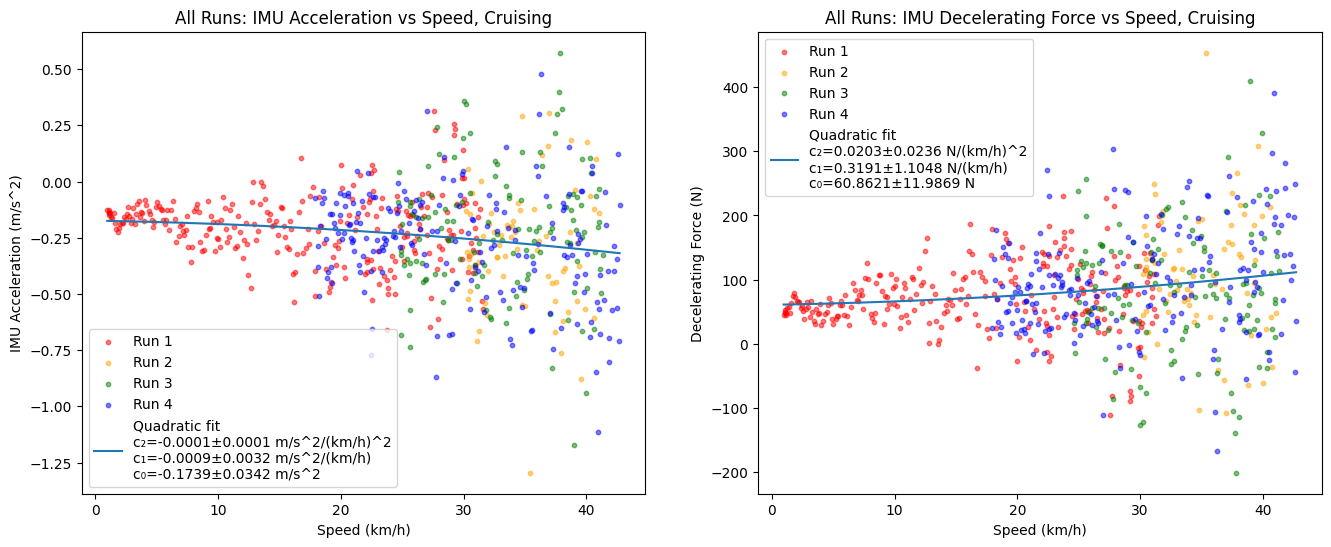

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ax_imu_accel, ax_imu_force = axes

for i, (speed, imu_z) in enumerate(zip(cruise_window_speeds, cruise_window_imu_zs)):
    speed_without_last = np.asarray(speed)[:-1]
    imu_z_without_last = np.asarray(imu_z)[:-1]
    imu_force = BRIGHTSIDE_MASS_KG * imu_z_without_last * -1
    color = COLORS[i]

    for ax, y_data, y_label, title in [
        (ax_imu_accel, imu_z_without_last, "IMU Acceleration (m/s^2)", "All Runs: IMU Acceleration vs Speed, Cruising"),
        (ax_imu_force, imu_force,          "Decelerating Force (N)",  "All Runs: IMU Decelerating Force vs Speed, Cruising"),
    ]:
        ax.scatter(speed_without_last, y_data, c=color, alpha=0.5, s=10, label=f"Run {i+1}")
        ax.set_title(title)
        ax.set_xlabel("Speed (km/h)")
        ax.set_ylabel(y_label)

for ax, coeffs, stdevs, y_label in [
    (ax_imu_accel, coeffs_accel, stdevs_accel, "m/s^2"),
    (ax_imu_force, coeffs_force, stdevs_force, "N"),
]:
    c2, c1, c0 = coeffs
    stdev2, stdev1, stdev0 = stdevs
    fit_label = (f"Quadratic fit\n"
                 f"c₂={c2:.4f}±{stdev2:.4f} {y_label}/(km/h)^2\n"
                 f"c₁={c1:.4f}±{stdev1:.4f} {y_label}/(km/h)\n"
                 f"c₀={c0:.4f}±{stdev0:.4f} {y_label}")
    ax.plot(v_range, np.polyval(coeffs, v_range), label=fit_label)


ax_imu_accel.legend()
ax_imu_force.legend()
plt.show()

### plotting all runs together

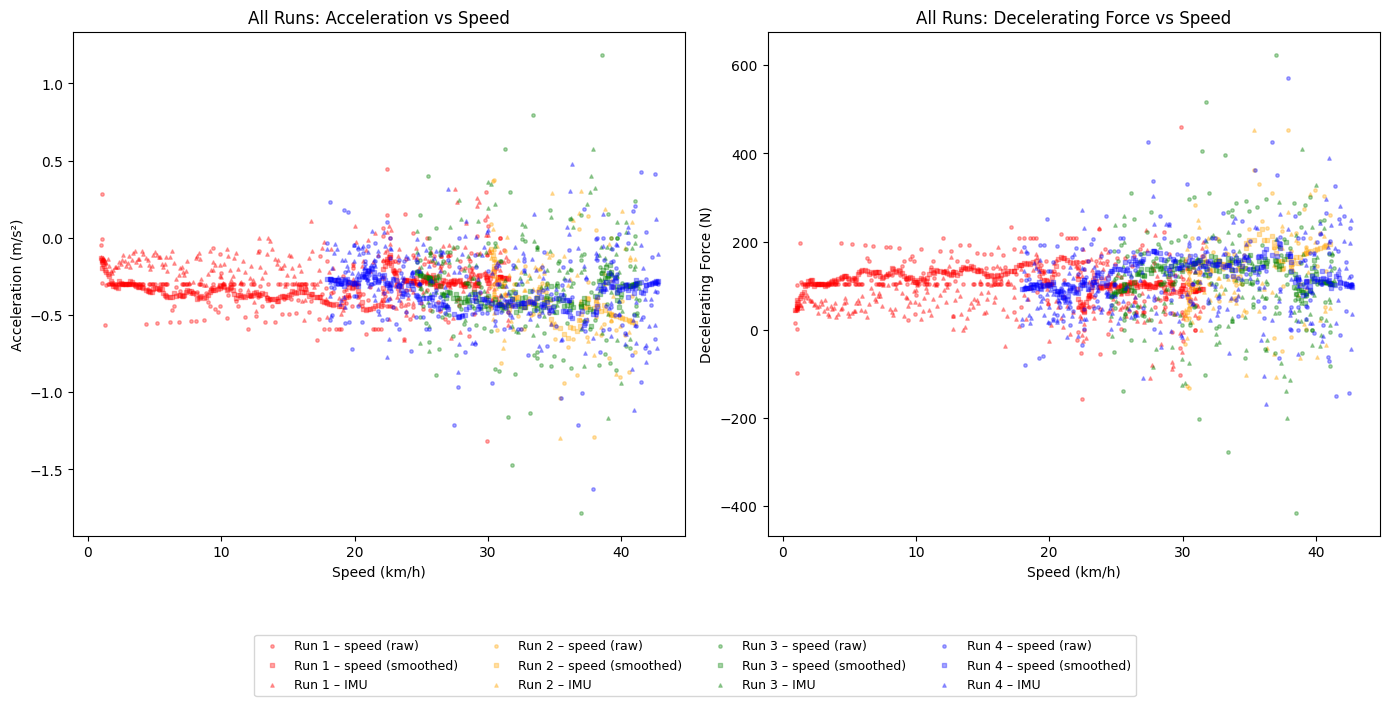

In [19]:
PROPERTIES = [
    # (label_suffix,  marker, alpha, size)
    ("speed (raw)",      "o", 0.33, 6),
    ("speed (smoothed)", "s", 0.33, 6),
    ("IMU",              "^", 0.33, 6),
]

fig, (ax_accel, ax_force) = plt.subplots(1, 2, figsize=(14, 6))

for i, (speed, imu_z) in enumerate(zip(cruise_window_speeds, cruise_window_imu_zs)):
    period   = speed.period
    color    = COLORS[i]

    speed_array = np.asarray(speed)
    speed_smoothed = savgol_filter(speed_array, SAVGOL_WINDOW, SAVGOL_POLY)
    speed_without_last = speed_array[:-1]

    raw_accel: np.ndarray = (np.diff(speed_array)    / period) / KMH_PER_MPS
    smooth_accel: np.ndarray = (np.diff(speed_smoothed) / period) / KMH_PER_MPS
    imu_accel_array = np.asarray(imu_z[:-1])

    y_accels = [raw_accel, smooth_accel, imu_accel_array]
    y_forces  = [BRIGHTSIDE_MASS_KG * a * -1 for a in y_accels]

    for (suffix, marker, alpha, size), y_accel, y_force in zip(PROPERTIES, y_accels, y_forces):
        label = f"Run {i+1} – {suffix}"
        ax_accel.scatter(speed_without_last, y_accel,
                         c=color, marker=marker, alpha=alpha, s=size, label=label)
        ax_force.scatter(speed_without_last, y_force,
                         c=color, marker=marker, alpha=alpha, s=size, label=label)

for ax, title, ylabel in [
    (ax_accel, "All Runs: Acceleration vs Speed",       "Acceleration (m/s²)"),
    (ax_force, "All Runs: Decelerating Force vs Speed", "Decelerating Force (N)"),
]:
    ax.set_title(title)
    ax.set_xlabel("Speed (km/h)")
    ax.set_ylabel(ylabel)

# Legend outside to avoid covering data
handles, labels = ax_accel.get_legend_handles_labels()
fig.legend(handles, labels,
           loc="lower center", ncol=4, fontsize=9,
           frameon=True, bbox_to_anchor=(0.5, -0.18))

plt.tight_layout()
plt.show()

### acceleration vs time graphs

these graphs were originally presented with the acceleration/force vs time graphs, but they don"t really provide information neccessary for determining the CfA

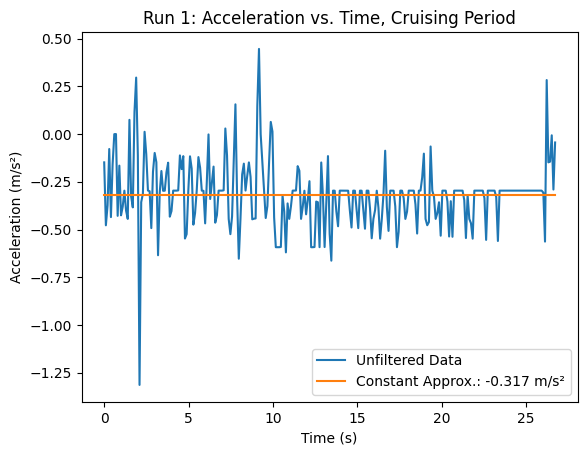

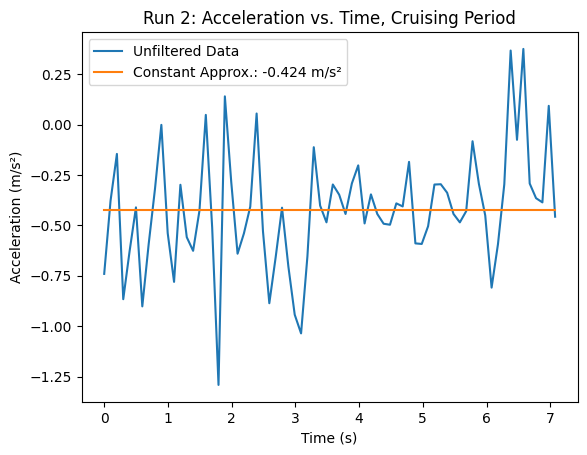

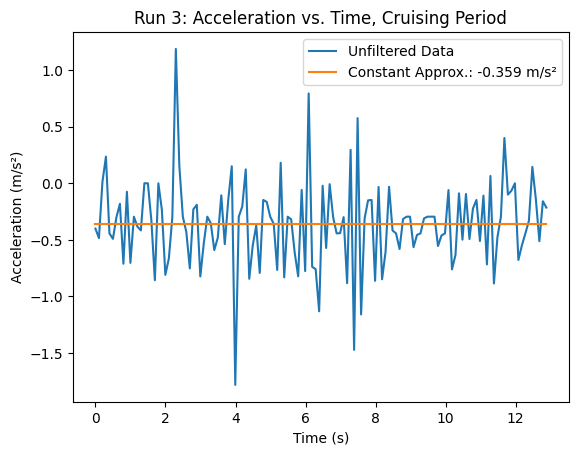

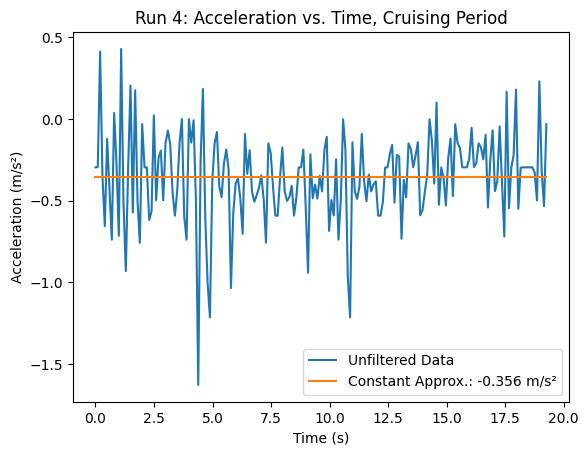

In [20]:
for i, speed in enumerate(cruise_window_speeds):
    period = speed.period
    t_axis = speed.x_axis

    acceleration = (np.diff(np.asarray(speed)) / period) / KMH_PER_MPS
    mean_accel = np.mean(acceleration)
    constant_approx = np.ones(len(acceleration)) * mean_accel

    plt.plot(t_axis[:-1], acceleration, label="Unfiltered Data")
    plt.plot(t_axis[:-1], constant_approx, label=f"Constant Approx.: {mean_accel:.3f} m/s²")
    plt.title(f"Run {i+1}: Acceleration vs. Time, Cruising Period")
    plt.ylabel("Acceleration (m/s²)")
    plt.xlabel("Time (s)")
    plt.legend()
    plt.show() 

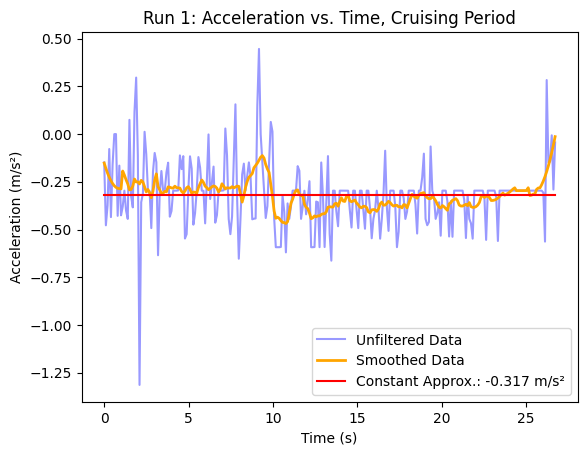

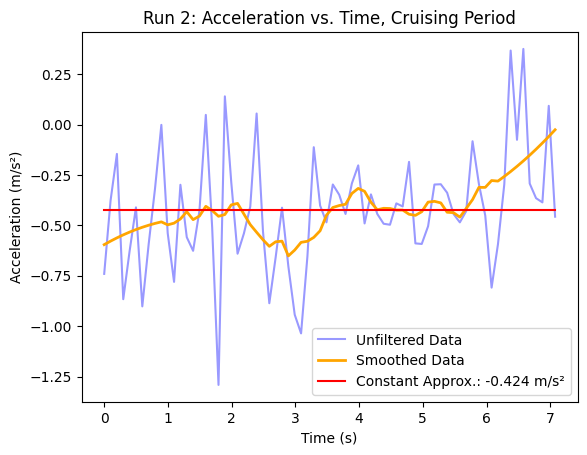

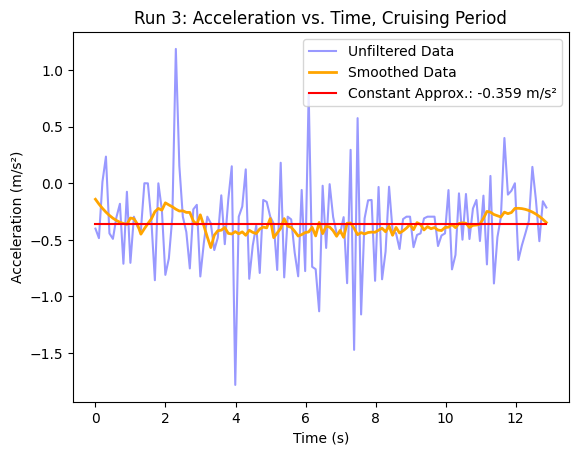

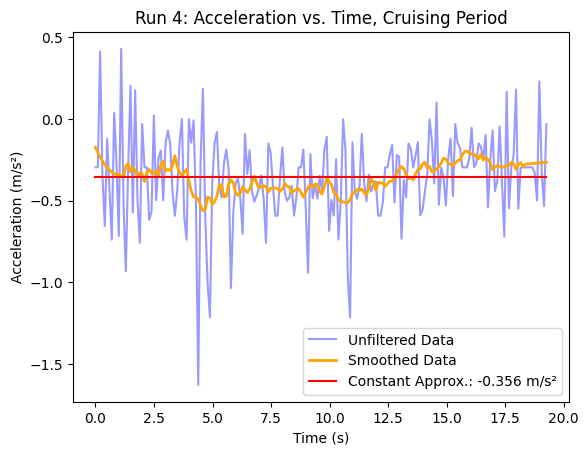

In [21]:
from scipy.signal import savgol_filter

SAVGOL_WINDOW = 21    # number of points in each window, must be odd — tune this
SAVGOL_POLY = 3       # polynomial order — 3 is standard

for i, speed in enumerate(cruise_window_speeds):
    period = speed.period
    t_axis = speed.x_axis

    speed_array = np.asarray(speed)
    speed_smoothed: np.ndarray = savgol_filter(speed_array, SAVGOL_WINDOW, SAVGOL_POLY)

    acceleration_raw: np.ndarray = (np.diff(speed_array) / period) / KMH_PER_MPS
    acceleration_smooth: np.ndarray = (np.diff(speed_smoothed) / period) / KMH_PER_MPS

    mean_accel = np.mean(acceleration_raw)
    constant_approx = np.ones(len(acceleration_raw)) * mean_accel

    plt.plot(t_axis[:-1], acceleration_raw, label="Unfiltered Data", alpha=0.4, color="blue")
    plt.plot(t_axis[:-1], acceleration_smooth, label="Smoothed Data", color="orange", linewidth=2)
    plt.plot(t_axis[:-1], constant_approx, label=f"Constant Approx.: {mean_accel:.3f} m/s²", color="red")
    plt.title(f"Run {i+1}: Acceleration vs. Time, Cruising Period")
    plt.ylabel("Acceleration (m/s²)")
    plt.xlabel("Time (s)")
    plt.legend()
    plt.show()